In [1]:

import os
from typing import Tuple

import matplotlib.pyplot as plt
import mne
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks, filtfilt, firwin, kaiserord



# Methods



## Helper Functions



In [3]:

def zscore(x):
    """Standardize a vector using its own mean and standard deviation."""
    return (x - x.mean()) / x.std()



In [4]:
def kaiser_lowpass(data, fs, cutoff, stopband_offset=10, atten_db=60):
    """Zero-phase low-pass FIR using Kaiser window."""
    nyq = fs / 2
    width = (stopband_offset) / nyq
    ntaps, beta = kaiserord(atten_db, width)
    coeff = firwin(ntaps, cutoff / nyq, window=('kaiser', beta))
    return filtfilt(coeff, 1.0, data)

In [5]:
def load_bipolar_hpc(fn, drop_chs, hpc_ch, ref_ch, return_ref):
    """Loads raw data, applies bipolar reference to HPC, and optionally returns average reference."""
    if fn.endswith('.edf'):
        raw = mne.io.read_raw_edf(fn, preload=False, verbose='ERROR')
    elif fn.endswith('.fif') or fn.endswith('.fif.gz'):
        raw = mne.io.read_raw_fif(fn, preload=False, verbose='ERROR')
    else:
        raise ValueError(f"Unsupported file format: {fn}")

    if len(drop_chs) > 0:
        raw.drop_channels(drop_chs, on_missing='ignore')
    raw.load_data(verbose='ERROR')

    # Create bipolar HPC channel
    hpc_raw = raw.copy().pick_channels([hpc_ch, ref_ch], verbose='ERROR')
    hpc_bp = mne.set_bipolar_reference(
        hpc_raw, anode=hpc_ch, cathode=ref_ch, drop_refs=True, copy=True, verbose='ERROR'
    )

    if not return_ref:
        return hpc_bp

    # Create average reference for artifact rejection
    _, ref_data = mne.set_eeg_reference(raw, ref_channels='average', projection=False, verbose='ERROR')
    ref_info = mne.create_info(['ref_channel'], raw.info['sfreq'], ch_types='eeg', verbose='ERROR')
    ref_raw = mne.io.RawArray(np.expand_dims(ref_data, axis=0), ref_info, first_samp=raw.first_samp, verbose='ERROR')
    
    return hpc_bp, ref_raw

In [6]:

def filter_hilbert(raw, l_freq, h_freq, trans_width=5, buffer_sec=30, **filter_kwargs):
    """
    Bandpass-filter data, compute the Hilbert envelope, and crop buffer edges.

    Returns
    -------
    lfp : ndarray
        Filtered local field potential after buffer cropping.
    amp : ndarray
        Hilbert amplitude envelope after buffer cropping.
    """
    filtered = raw.copy().filter(
        l_freq=l_freq,
        h_freq=h_freq,
        l_trans_bandwidth=trans_width,
        h_trans_bandwidth=trans_width,
        n_jobs=-1,
        verbose="ERROR",
        **filter_kwargs,
    )

    cropped = filtered.copy().crop(
        tmin=buffer_sec,
        tmax=raw.tmax - buffer_sec,
        verbose="ERROR",
    )
    lfp = cropped.get_data()[0]

    amp = (
        filtered.apply_hilbert(envelope=True, n_jobs=-1, verbose="ERROR")
        .crop(tmin=buffer_sec, tmax=raw.tmax - buffer_sec, verbose="ERROR")
        .get_data()[0]
    )

    return lfp, amp



In [7]:
def remove_peaks_near_artifacts(peak_signal, artifact_peak_lists, signal_len, fs, window_ms):
    """Masks out peaks that fall within a specified window of artifact events."""
    window_samples = int(window_ms * fs / 1000)
    artifact_mask = np.zeros(signal_len, dtype=bool)
    
    all_artifacts = np.concatenate(artifact_peak_lists) if artifact_peak_lists else np.array([])
    for p in all_artifacts:
        start, end = max(0, p - window_samples), min(signal_len, p + window_samples + 1)
        artifact_mask[start:end] = True
        
    return peak_signal[~artifact_mask[peak_signal]]

In [8]:
def expand(peaks, threshold_mask):
    """Expands around peaks until the signal drops below the edge threshold."""
    starts = np.where(np.diff(np.pad(threshold_mask.astype(int), (1, 1))) == 1)[0]
    ends = np.where(np.diff(np.pad(threshold_mask.astype(int), (1, 1))) == -1)[0] - 1

    ripples = []
    for p in peaks:
        idx = np.where((starts <= p) & (ends >= p))[0]
        if len(idx):
            i = idx[0]
            ripples.append([starts[i], p, ends[i]])

    return np.array(ripples, dtype=int)

In [9]:
def duration_filter(ripples, tmin, tmax):
    """Keep ripples within duration bounds (in samples)."""
    dur = ripples[:, -1] - ripples[:, 0]
    return ripples[(dur >= tmin) & (dur <= tmax)]

In [10]:
def merge_ripples(ripples, threshold, mode):
    """
    Merges adjacent ripples. 
    mode='peak': Merges if peak-to-peak distance < threshold (Norman).
    mode='gap': Merges if off-to-on gap < threshold (Vaz).
    """
    if len(ripples) < 2:
        return ripples

    merged = []
    curr = ripples[0].copy()
    
    for nxt in ripples[1:]:
        dist = (nxt[1] - curr[1]) if mode == 'peak' else (nxt[0] - curr[2])
        if dist < threshold:
            curr[2] = max(curr[2], nxt[2])  # Extend the end of the current ripple
        else:
            merged.append(curr)
            curr = nxt.copy()
            
    merged.append(curr)
    return np.array(merged)

In [11]:
def find_negative_peaks(lfp, ripples):
    """Find trough closest to envelope peak."""
    neg_idx = np.zeros(len(ripples), dtype=int)

    for i, (start, peak, end) in enumerate(ripples):
        troughs, _ = find_peaks(-lfp[start:end])
        if len(troughs) == 0:
            neg_idx[i] = -1
            continue
        rel = peak - start
        closest = troughs[np.argmin(np.abs(troughs - rel))]
        neg_idx[i] = start + closest

    return neg_idx

## Ripple Detection Function



In [12]:
def detect_ripples(
    fif_fn: str,
    drop_chs: list,
    hpc_channel: str,
    ref_channel: str,
    tmin: int,
    tmax: int,
    params: dict,
    mode: str = "norman"
) -> Tuple[np.ndarray, mne.Epochs]:
    """
    Detect ripples with either the Norman or Vaz parameter set.

    Parameters in `params` are kept explicit below so each published branch can be
    inspected and adjusted without changing the detection logic.
    """

    # Load data.
    hpc, ref = load_bipolar_hpc(fif_fn, drop_chs, hpc_channel, ref_channel, return_ref=True)
    sfreq = hpc.info['sfreq']

    # Compute the ripple-band signal and method-specific artifact masks.
    lfp, amp = filter_hilbert(hpc, params['l_freq'], params['h_freq'],
                          trans_width=params['trans_width'],
                          buffer_sec=params['buffer_sec'],
                          **params['filter_kwargs'])
    if mode == "norman":
        # --- Clip extreme power outliers and smooth ---
        clip_extreme = amp.mean() + params['clip_SD'] * amp.std()
        clip_signal = np.minimum(amp, clip_extreme)
        clip_power = clip_signal ** 2

        smooth_clipped = kaiser_lowpass(clip_power, sfreq, params['kaiser_cutoff'])
        z_signal = zscore(smooth_clipped)

        del clip_extreme, clip_signal, clip_power, smooth_clipped

        # --- Artifact rejection: IED ---
        _, amp_ied = filter_hilbert(hpc, params['l_freq_ied'], params['h_freq_ied'],
                                trans_width=params['trans_width'],
                                buffer_sec=params['buffer_sec'],
                                **params['filter_kwargs'])
        z_ied = zscore(kaiser_lowpass(amp_ied ** 2, sfreq, params['kaiser_cutoff']))

        del amp_ied

        # --- Artifact rejection: CAR reference ---
        _, amp_ref = filter_hilbert(ref, params['l_freq'], params['h_freq'],
                                trans_width=params['trans_width'],
                                buffer_sec=params['buffer_sec'],
                                **params['filter_kwargs'])
        z_ref = zscore(kaiser_lowpass(amp_ref ** 2, sfreq, params['kaiser_cutoff']))

        del amp_ref
        
        # --- Peak Detection & Artifact Removal ---
        peaksA, _ = find_peaks(z_signal, height=params['peak_SD'])
        peaksB, _ = find_peaks(z_ref, height=params['peak_SD'])
        peaksC, _ = find_peaks(z_ied, height=params['peak_SD'])

        del ref, z_ref, z_ied
    
    elif mode == "vaz":
        z_signal = zscore(amp)

        lfp_ied, amp_ied = filter_hilbert(hpc, params['l_freq_ied'], params['h_freq_ied'],
                                trans_width=params['trans_width'],
                                buffer_sec=params['buffer_sec'],
                                **params['filter_kwargs'])
        z_ied_amp = zscore(amp_ied)
        z_ied_grad = zscore(np.gradient(lfp_ied))
        del amp_ied

        peaksA, _ = find_peaks(z_signal, height=params['peak_SD'])
        peaksB, _ = find_peaks(z_ied_amp, height=params['ied_SD'])
        peaksC, _ = find_peaks(z_ied_grad, height=params['ied_SD'])

        del ref, z_ied_amp, z_ied_grad
    
    else:
        raise ValueError("mode must be 'norman' or 'vaz'")
    
    # --- Peak Detection & Artifact Removal ---
    ripple_cands = remove_peaks_near_artifacts(peaksA, [peaksB, peaksC], len(z_signal), sfreq, params['artifact_ms'])    


    # --------------------------------------------------
    # Expand peaks to regions
    # --------------------------------------------------
    ripples = expand(ripple_cands, z_signal >= params['edge_SD'])

    # --------------------------------------------------
    # Duration filtering
    # --------------------------------------------------
    ripples = duration_filter(ripples, params['min_duration'], params['max_duration'])

    # --------------------------------------------------
    # Merge
    # --------------------------------------------------
    ripples = merge_ripples(ripples, **params['merge_kws'])
    
    neg_peaks = find_negative_peaks(lfp, ripples)
    ripples[:, 1] = neg_peaks


    # --------------------------------------------------
    # Epoch extraction
    # --------------------------------------------------

    hpc.crop(tmin=params['buffer_sec'], tmax=hpc.tmax - params['buffer_sec'])
    events = np.column_stack((
        neg_peaks + hpc.first_samp,
        np.zeros_like(neg_peaks),
        np.ones_like(neg_peaks)
    ))

    epochs = mne.Epochs(
        hpc,
        events,
        event_id=1,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        verbose='ERROR'
    )


    return ripples, epochs



# Configuration and Main Workflow



In [17]:

# Channel placeholders. Set these explicitly before running detection.
hpc_channel = ""
ref_channel = ""
drop_chs = []



In [18]:

# Data configuration. Defaults preserve the original analysis environment.
dir_path = r"E:\sEEG"
os.chdir(dir_path)

expt_version = "Exp1"
hpc_subjs = ["CLC", "GTQ", "LZ", "WZQ", "SRB", "ZZL", "ZLX", "YG"]
sub_list = os.listdir(expt_version)

sub = "SRB"
hpc_channel, ref_channel = "POL K4", "POL K9"
fif_fn = r"E:\sEEG\Exp1\SRB\Re\SRB_Session3_ieeg.fif.gz"

sub_path = os.path.join(expt_version, sub, "Re")
noisy_chs = np.load(os.path.join(sub_path, f"{sub}_Noisy_chs_kurt.npz"))["noisy_chs"]
drop_chs = np.setdiff1d(noisy_chs, [hpc_channel, ref_channel])



## Norman: [link](https://www.science.org/doi/10.1126/science.aax1030)

In [ ]:
params = dict(
    l_freq=70,
    h_freq=180,
    trans_width=5,
    filter_kwargs=dict(method='fir', phase='zero', fir_window='hamming'),
    
    peak_SD=4,
    edge_SD=2,
    clip_SD=4,
    
    kaiser_cutoff=40,
    
    l_freq_ied=25,
    h_freq_ied=60,
    
    artifact_ms=50,
    merge_kws=dict(mode='peak', threshold=30),
    
    min_duration=20,
    max_duration=200,
    
    buffer_sec=30,
)

In [ ]:
ripples, epochs = detect_ripples(fif_fn, drop_chs, hpc_channel, ref_channel, tmin=-1, tmax=1, params=params, mode='norman')
group_lfp = epochs.get_data()[:,0]

## Vaz: [link](https://www.science.org/doi/10.1126/science.aau8956)

In [21]:
params = dict(
    l_freq=80,
    h_freq=120,
    trans_width=5,
    filter_kwargs=dict(method='iir', phase='zero', iir_params={'order': 2, 'ftype': 'butter'}),
    
    peak_SD=3,
    edge_SD=2,
    ied_SD=5,
    

    l_freq_ied=250,
    h_freq_ied=None,
    
    artifact_ms=100,
    merge_kws=dict(mode='gap', threshold=15),
    
    min_duration=25,
    max_duration=np.inf,
    
    buffer_sec=30,
)

In [22]:
ripples, epochs = detect_ripples(fif_fn, drop_chs, hpc_channel, ref_channel, tmin=-1, tmax=1, params=params, mode='vaz')
group_lfp = epochs.get_data()[:,0]

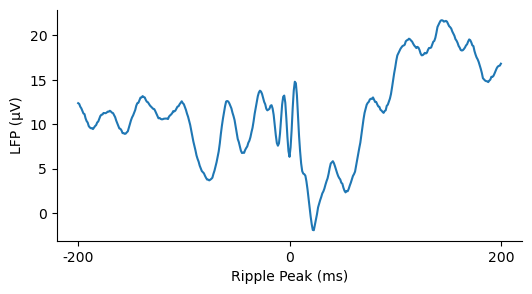

In [23]:
fig, ax = plt.subplots(figsize=(6,3))  # Convert cm to inches

_u = np.mean(group_lfp, axis=0)[800:-800]  * 1e6
_err = stats.sem(group_lfp, axis=0)[800:-800]  * 1e6

# Plot the mean LFP
ax.plot(_u,  zorder=5)

# Customize the plot
ax.set_xticks([0, 200, 400])
ax.set_xticklabels([-200, 0, 200])
ax.set_xlabel('Ripple Peak (ms)')
ax.set_ylabel('LFP (µV)')
sns.despine(ax=ax)

plt.show()